In [3]:
%load_ext autoreload
%autoreload 2

In [2]:
import kagglehub

path = kagglehub.dataset_download("danielbacioiu/tig-aluminium-5083")

print("Path to dataset files:", path)

Path to dataset files: /Users/parth/.cache/kagglehub/datasets/danielbacioiu/tig-aluminium-5083/versions/1


In [4]:
import pandas as pd

path = "/Users/parth/.cache/kagglehub/datasets/danielbacioiu/tig-aluminium-5083/versions/1"

# list files
import os
print(os.listdir(path))

['al5083']


In [5]:
import os

base_path = "/Users/parth/.cache/kagglehub/datasets/danielbacioiu/tig-aluminium-5083/versions/1"

print("Level 1:", os.listdir(base_path))

Level 1: ['al5083']


In [6]:
correct_path = os.path.join(base_path, "al5083")

print("Level 2:", os.listdir(correct_path))

Level 2: ['test', 'al5083', 'README', 'train']


In [7]:
import os

root = "/Users/parth/.cache/kagglehub/datasets/danielbaciuiu/tig-aluminium-5083"

for dirpath, dirnames, filenames in os.walk(root):
    print(dirpath)

In [8]:
train_path = os.path.join(correct_path, "train")
test_path = os.path.join(correct_path, "test")

print(os.listdir(train_path)[:5])

['170815-134756-Al 2mm', '170904-115503-Al 2mm', '170913-155806-Al 2mm-part1', '170906-113317-Al 2mm-part3', '170904-152301-Al 2mm-part1']


In [9]:
print(os.listdir(train_path))

['170815-134756-Al 2mm', '170904-115503-Al 2mm', '170913-155806-Al 2mm-part1', '170906-113317-Al 2mm-part3', '170904-152301-Al 2mm-part1', '170904-141730-Al 2mm-part3', '170904-113012-Al 2mm-part1', '170906-141809-Al 2mm-part1', '170904-151845-Al 2mm-part1', '170904-141730-Al 2mm-part2', '170913-152931-Al 2mm-part1', '170904-154202-Al 2mm-part2', '170904-141232-Al 2mm-part1', '170906-153326-Al 2mm-part2', '170906-114912-Al 2mm', '170904-150144-Al 2mm-part1', '170913-151508-Al 2mm-part1', '170905-110711-Al 2mm-part1', '170913-140725-Al 2mm', '170913-142501-Al 2mm', '170904-145718-Al 2mm-part1', '170913-143933-Al 2mm-part2', '170906-151353-Al 2mm', '170913-155806-Al 2mm-part2', '170906-120346-Al 2mm', '170904-141232-Al 2mm-part3', '170904-113012-Al 2mm-part2', '170905-114307-Al 2mm', '170904-112347-Al 2mm', 'train.json', '170904-141232-Al 2mm-part2', '170906-153326-Al 2mm-part1', '170906-141809-Al 2mm-part2', '170904-151845-Al 2mm-part2', '170913-152931-Al 2mm-part2', '170904-141730-Al 2

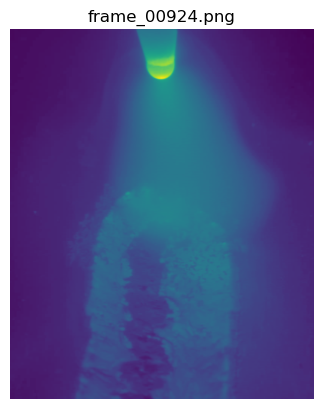

In [10]:
import matplotlib.pyplot as plt
from PIL import Image
import os

for folder in os.listdir(train_path):
    folder_path = os.path.join(train_path, folder)

    if os.path.isdir(folder_path):
        for file in os.listdir(folder_path):
            if file.lower().endswith(('.jpg', '.png', '.jpeg')):
                img_path = os.path.join(folder_path, file)

                img = Image.open(img_path)

                plt.imshow(img)
                plt.axis('off')
                plt.title(file)
                plt.show()

                break
        break

In [11]:
import os, shutil, json

BASE_PATH = correct_path

LABEL_MAP = {
    0: "good",
    1: "burn_through",
    2: "contamination",
    3: "lack_of_fusion",
    4: "misalignment",
    5: "lack_of_penetration"
}

train_dir = os.path.join(BASE_PATH, "train")
out_dir = "data/organized"

print(" Train dir:", train_dir)
print("Exists?", os.path.exists(train_dir))
print(" Files in train:", os.listdir(train_dir)[:5])

os.makedirs(out_dir, exist_ok=True)

# Create class folders
for label in LABEL_MAP.values():
    folder_path = os.path.join(out_dir, label)
    os.makedirs(folder_path, exist_ok=True)
    print(" Created:", folder_path)

# Load JSON
json_path = os.path.join(train_dir, "train.json")
print(" JSON path:", json_path)

with open(json_path) as f:
    data = json.load(f)

print(" Total annotations:", len(data))
print(" Sample:", list(data.items())[:3])

copied, skipped = 0, 0

for i, (img_rel, label_id) in enumerate(data.items()):
    label_name = LABEL_MAP[label_id]

    src = os.path.join(train_dir, img_rel)
    dst = os.path.join(out_dir, label_name, img_rel.replace("/", "_"))

    if os.path.exists(src):
        shutil.copy2(src, dst)
        copied += 1
    else:
        skipped += 1

    # print first few copies
    if i < 5:
        print(f" Copying: {img_rel} → {label_name}")

print("\n FINAL:")
print(f" Copied: {copied}")
print(f"Skipped: {skipped}")

 Train dir: /Users/parth/.cache/kagglehub/datasets/danielbacioiu/tig-aluminium-5083/versions/1/al5083/train
Exists? True
 Files in train: ['170815-134756-Al 2mm', '170904-115503-Al 2mm', '170913-155806-Al 2mm-part1', '170906-113317-Al 2mm-part3', '170904-152301-Al 2mm-part1']
 Created: data/organized/good
 Created: data/organized/burn_through
 Created: data/organized/contamination
 Created: data/organized/lack_of_fusion
 Created: data/organized/misalignment
 Created: data/organized/lack_of_penetration
 JSON path: /Users/parth/.cache/kagglehub/datasets/danielbacioiu/tig-aluminium-5083/versions/1/al5083/train/train.json
 Total annotations: 26666
 Sample: [('170906-113317-Al 2mm-part3/frame_00647.png', 1), ('170906-113317-Al 2mm-part3/frame_00672.png', 1), ('170906-113317-Al 2mm-part3/frame_00677.png', 1)]
 Copying: 170906-113317-Al 2mm-part3/frame_00647.png → burn_through
 Copying: 170906-113317-Al 2mm-part3/frame_00672.png → burn_through
 Copying: 170906-113317-Al 2mm-part3/frame_00677.

In [12]:
import shutil, os

src = "data/organized"
dst = "data/full"

os.makedirs(dst, exist_ok=True)

total = 0

for folder in os.listdir(src):
    src_folder = os.path.join(src, folder)
    dst_folder = os.path.join(dst, folder)

    os.makedirs(dst_folder, exist_ok=True)

    files = os.listdir(src_folder)

    print(f" {folder}: {len(files)} images")

    for f in files:
        shutil.copy(
            os.path.join(src_folder, f),
            os.path.join(dst_folder, f)
        )
        total += 1

print(f"\n DONE: Copied {total} images")

 burn_through: 1783 images
 lack_of_fusion: 4028 images
 good: 8758 images
 misalignment: 2953 images
 contamination: 6325 images
 lack_of_penetration: 2819 images

 DONE: Copied 26666 images


In [13]:
import sys
sys.path.append("MV_PROJECT")

In [14]:
from features.feature_extractor import FeatureExtractor
from classifier.trainer import ModelTrainer
import classifier.trainer as t

# Patch label map
t.LABEL_MAP = {
    "good": ("Good", None),
    "burn_through": ("Bad", "Burn Through"),
    "contamination": ("Bad", "Contamination"),
    "lack_of_fusion": ("Bad", "Lack of Fusion"),
    "misalignment": ("Bad", "Misalignment"),
    "lack_of_penetration": ("Bad", "Lack of Penetration"),
}

extractor = FeatureExtractor()

trainer = ModelTrainer(
    extractor,
    model_type="svm"   
)

trainer.train("data/full", model_dir="models")


[Trainer] Loading dataset from: data/full
  good: 8758 images
  burn_through: 1783 images
  contamination: 6325 images
  lack_of_fusion: 4028 images
  misalignment: 2953 images
  lack_of_penetration: 2819 images
[Trainer] 26666 samples loaded.

[Trainer] Training binary classifier...
              precision    recall  f1-score   support

         Bad       0.99      0.97      0.98      3582
        Good       0.94      0.99      0.96      1752

    accuracy                           0.98      5334
   macro avg       0.97      0.98      0.97      5334
weighted avg       0.98      0.98      0.98      5334

  Cross-val F1 (binary): 0.934 ± 0.035

[Trainer] Training defect-type classifier...
                     precision    recall  f1-score   support

       Burn Through       0.99      1.00      1.00       356
      Contamination       1.00      0.98      0.99      1265
     Lack of Fusion       1.00      1.00      1.00       806
Lack of Penetration       0.96      1.00      0.98       

In [14]:
import os

BASE_PATH = "/Users/parth/.cache/kagglehub/datasets/danielbacioiu/tig-aluminium-5083/versions/1/al5083"
test_dir = os.path.join(BASE_PATH, "test")

folders = os.listdir(test_dir)
print(folders[:5])

['170906-153326-Al 2mm-part3', '170906-143512-Al 2mm-part1', '170906-155007-Al 2mm-part1', 'test.json', '170906-104925-Al 2mm']


  [Classifier] Loaded trained models from models

  Welding Defect Detection Pipeline
  Image : frame_00216.png

[1/5] Preprocessing...
[2/5] Segmentation...
[3/5] Extracting features...
[4/5] Classifying...
[5/5] Saving to database...
  Saved report: results/frame_00216_report.jpg

────────────────────────────────────────────────────────────
  RESULT
────────────────────────────────────────────────────────────
  Status      : ✓ GOOD
  Confidence  : 92.5%

  Feature Summary:
    Contrast      = 3.0494
    Energy        = 0.7614
    Homogeneity   = 0.9273
    LBP score     = 0.1854
    Circularity   = 0.1036
    Edge density  = 0.0018
    Area (px²)   = 180795
────────────────────────────────────────────────────────────


  Welding Defect Detection Pipeline
  Image : frame_00617.png

[1/5] Preprocessing...
[2/5] Segmentation...
[3/5] Extracting features...
[4/5] Classifying...
[5/5] Saving to database...
  Saved report: results/frame_00617_report.jpg

───────────────────────────────────

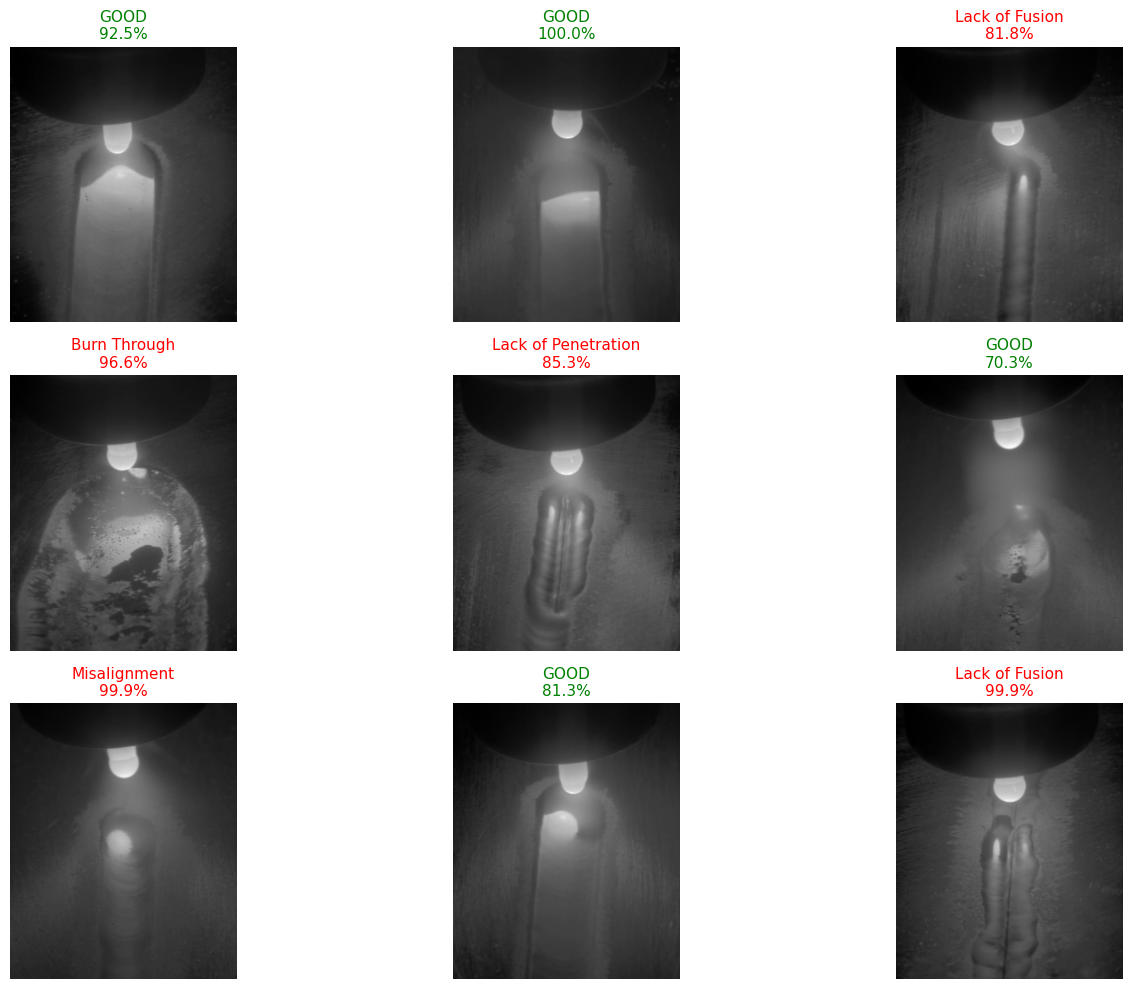

In [15]:
import matplotlib.pyplot as plt
import cv2
import os
import random

from pipeline import WeldingDefectPipeline

# initialize pipeline
pipeline = WeldingDefectPipeline(model_dir="models")

# get valid folders (ignore test.json)
folders = [f for f in os.listdir(test_dir) if os.path.isdir(os.path.join(test_dir, f))]

# shuffle for variety
random.shuffle(folders)

# number of images
num_images = 9

# grid size
rows = 3
cols = 3

plt.figure(figsize=(15,10))

for i in range(num_images):
    folder_path = os.path.join(test_dir, folders[i % len(folders)])

    # pick random image from folder (better than always first)
    image_name = random.choice(os.listdir(folder_path))
    image_path = os.path.join(folder_path, image_name)

    # run pipeline
    result = pipeline.run(image_path)

    # read image
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # title formatting
    if result["status"] == "Good":
        title = f"GOOD\n{result['confidence']:.1f}%"
        color = "green"
    else:
        title = f"{result['defect_type']}\n{result['confidence']:.1f}%"
        color = "red"

    # plot
    plt.subplot(rows, cols, i+1)
    plt.imshow(img)
    plt.title(title, color=color, fontsize=11)
    plt.axis("off")

plt.tight_layout()
plt.show()